In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


In [138]:
import pandas as pd
import numpy as np

train_path = r"D:\SIC\Final project\Data\Walmart Recruiting - Store Sales\train.csv"
features_path = r"D:\SIC\Final project\Data\Walmart Recruiting - Store Sales\features.csv"
stores_path = r"D:\SIC\Final project\Data\Walmart Recruiting - Store Sales\stores.csv"

train = pd.read_csv(train_path, parse_dates=['Date'])
features = pd.read_csv(features_path, parse_dates=['Date'])
stores = pd.read_csv(stores_path)


In [139]:
# Convert IsHoliday to bool
train["IsHoliday"] = train["IsHoliday"].astype(bool)
features["IsHoliday"] = features["IsHoliday"].astype(bool)

# Fill NA in MarkDowns with 0
md_cols = [c for c in features.columns if "MarkDown" in c]
features[md_cols] = features[md_cols].fillna(0)

# Fill economic missing with median
features["CPI"] = features["CPI"].fillna(features["CPI"].median())
features["Unemployment"] = features["Unemployment"].fillna(features["Unemployment"].median())


In [140]:
merged = train.merge(
    features,
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_feat")
)


In [141]:
merged = merged.merge(
    stores,
    on="Store",
    how="left"
)


In [142]:
print("Data loading and merging completed!")
print(f"Final dataset shape: {merged.shape}")
print("\nFirst 5 rows:")
display(merged.head())

Data loading and merging completed!
Final dataset shape: (421570, 17)

First 5 rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_feat,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,A,151315


In [143]:
print(merged.isnull().sum())

Store             0
Dept              0
Date              0
Weekly_Sales      0
IsHoliday         0
Temperature       0
Fuel_Price        0
MarkDown1         0
MarkDown2         0
MarkDown3         0
MarkDown4         0
MarkDown5         0
CPI               0
Unemployment      0
IsHoliday_feat    0
Type              0
Size              0
dtype: int64


#  Data preprocessing and cleaning


In [144]:
df = merged.copy()

# Extract date components for time series analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Quarter'] = df['Date'].dt.quarter


In [145]:

# Create seasonal features
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)


In [146]:

# Convert boolean to numeric for modeling
df['IsHoliday'] = df['IsHoliday'].astype(int)


In [147]:
# Create store-dept identifier
df['Store_Dept'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)


In [148]:
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (421570, 27)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Year,Month,Week,DayOfYear,Quarter,Month_sin,Month_cos,Week_sin,Week_cos,Store_Dept
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,2010,2,5,36,1,0.866025,5.000000e-01,0.568065,0.822984,1_1
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,2010,2,6,43,1,0.866025,5.000000e-01,0.663123,0.748511,1_1
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,2010,2,7,50,1,0.866025,5.000000e-01,0.748511,0.663123,1_1
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,2010,2,8,57,1,0.866025,5.000000e-01,0.822984,0.568065,1_1
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,2010,3,9,64,1,1.000000,6.123234e-17,0.885456,0.464723,1_1


#  Exploratory Data Analysis - Basic Overview


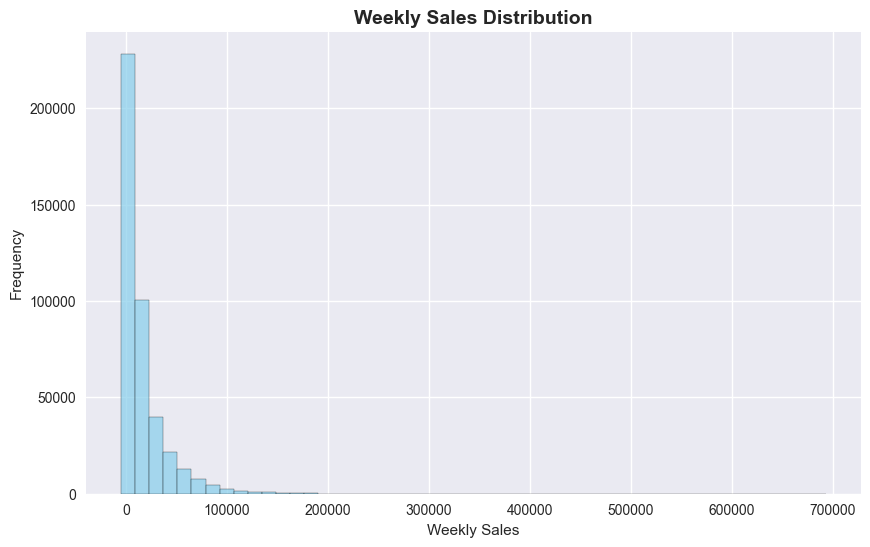

In [149]:
# 1. Sales distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Weekly_Sales'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Weekly Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()


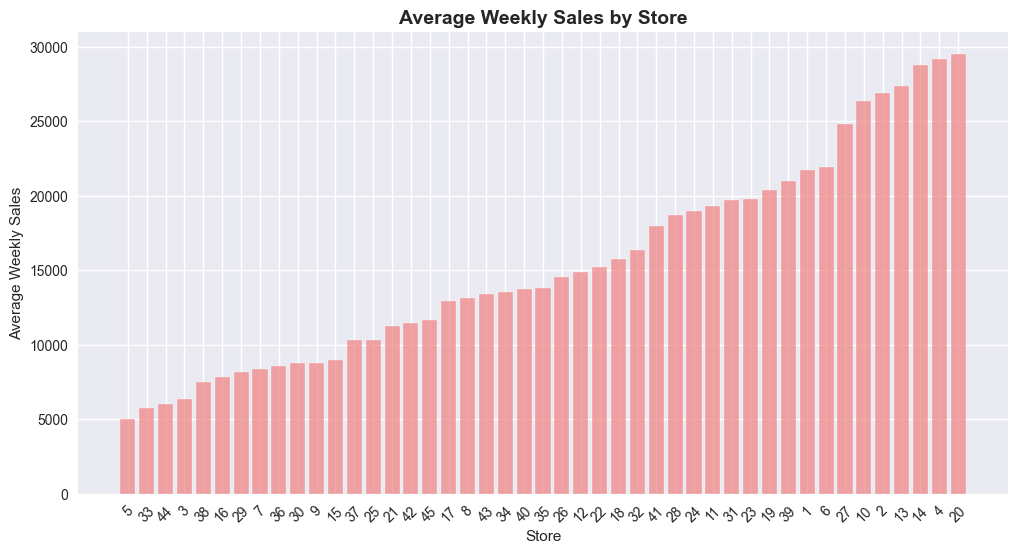

In [150]:
# 2. Sales by store
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values()

plt.figure(figsize=(12, 6))
plt.bar(store_sales.index.astype(str), store_sales.values, color='lightcoral', alpha=0.7)
plt.title('Average Weekly Sales by Store', fontsize=14, fontweight='bold')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.show()


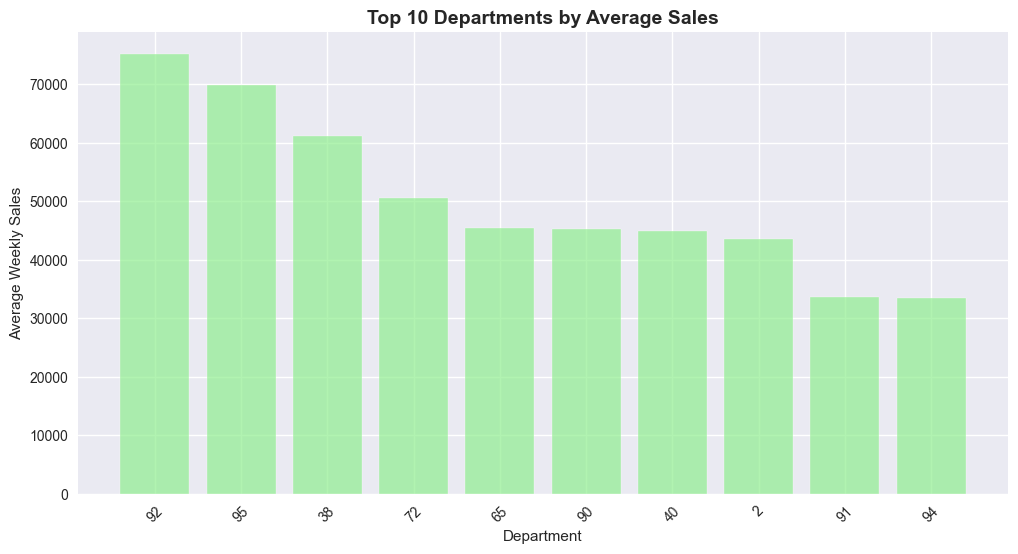

In [151]:
# 3. Sales by department
dept_sales = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(dept_sales.index.astype(str), dept_sales.values, color='lightgreen', alpha=0.7)
plt.title('Top 10 Departments by Average Sales', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.show()


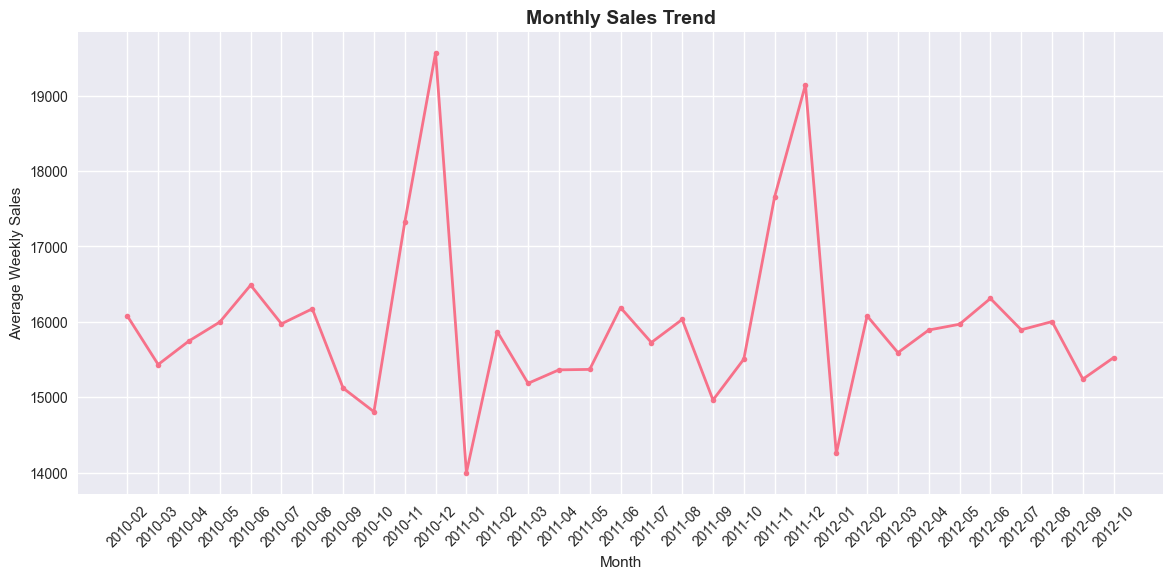

In [152]:
# 4. Sales trend over time
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Weekly_Sales'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2, markersize=4)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(rotation=45)
plt.show()


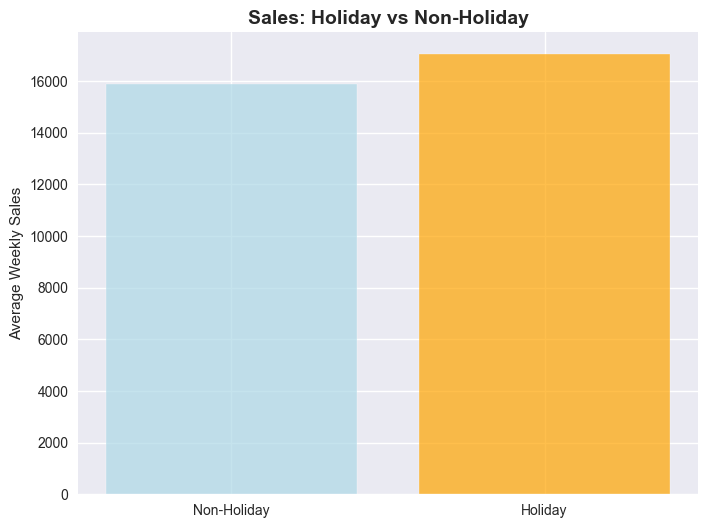

In [153]:
# 5. Holiday vs Non-Holiday sales
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(8, 6))
plt.bar(['Non-Holiday', 'Holiday'], holiday_sales.values, color=['lightblue', 'orange'], alpha=0.7)
plt.title('Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
plt.ylabel('Average Weekly Sales')
plt.show()


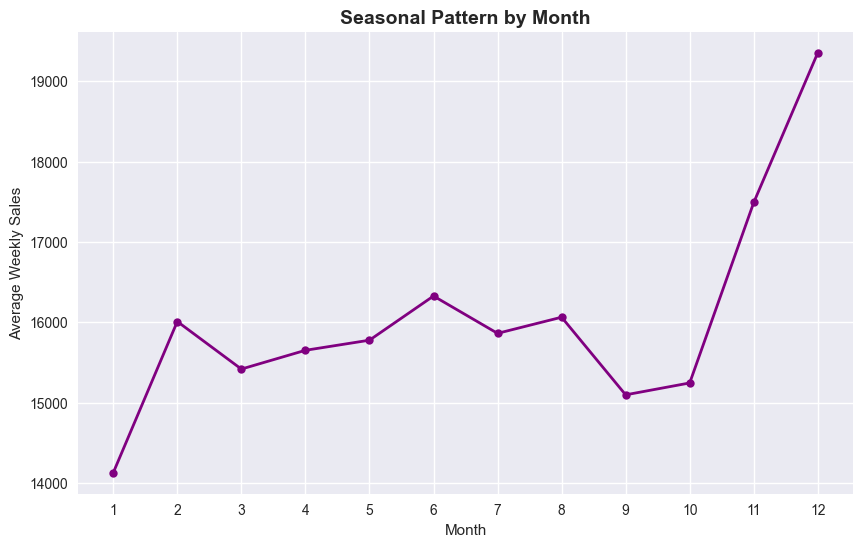

In [154]:
# 6. Seasonal pattern by month
monthly_pattern = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 6))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o', linewidth=2, color='purple', markersize=6)
plt.title('Seasonal Pattern by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(range(1, 13))
plt.show()


#   Time Series Analysis


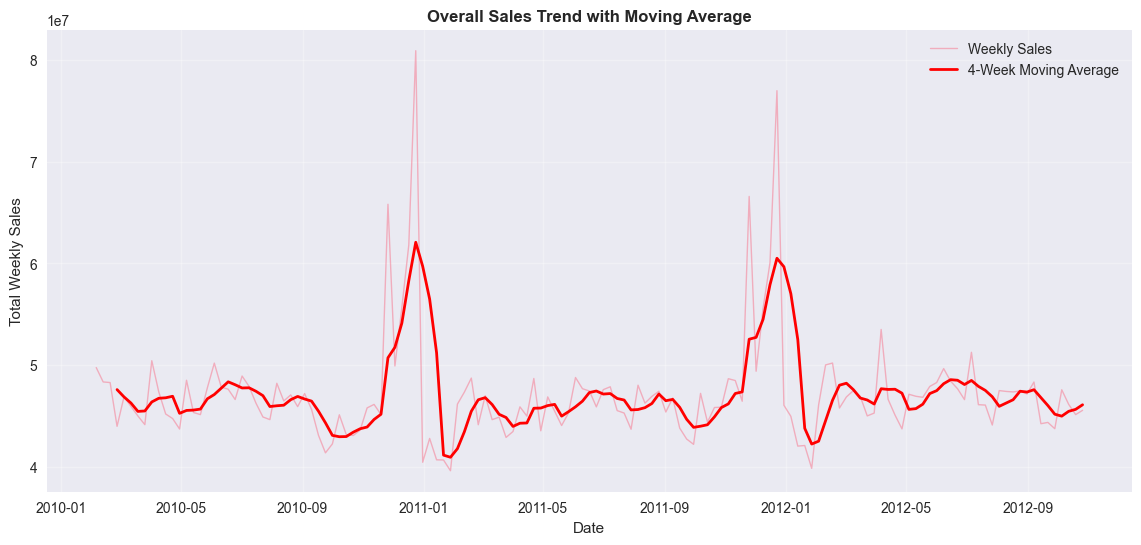

In [155]:
# 1. Overall sales trend with rolling average
overall_daily = df.groupby('Date')['Weekly_Sales'].sum()
rolling_avg = overall_daily.rolling(window=4).mean()

plt.figure(figsize=(14, 6))
plt.plot(overall_daily.index, overall_daily.values, alpha=0.5, label='Weekly Sales', linewidth=1)
plt.plot(rolling_avg.index, rolling_avg.values, label='4-Week Moving Average', linewidth=2, color='red')

plt.title('Overall Sales Trend with Moving Average', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


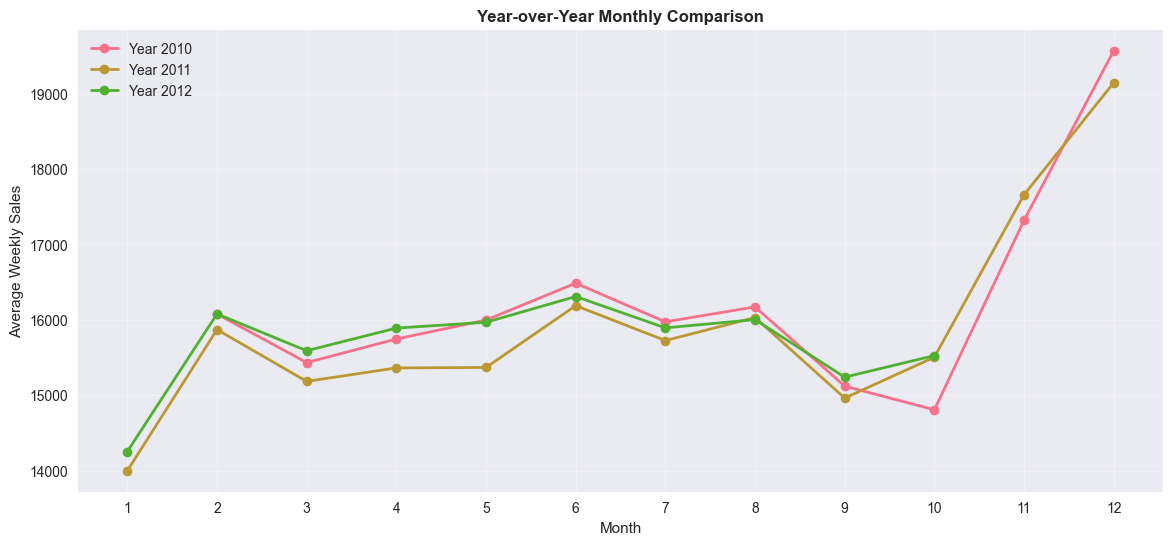

In [156]:
# 2. Year-over-year comparison
df['YearMonth'] = df['Date'].dt.to_period('M')

yearly_comparison = df.pivot_table(
    values='Weekly_Sales',
    index=df['Date'].dt.month,
    columns=df['Date'].dt.year,
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))
for year in yearly_comparison.columns:
    plt.plot(yearly_comparison.index, yearly_comparison[year], marker='o', linewidth=2, label=f'Year {year}')

plt.title('Year-over-Year Monthly Comparison', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


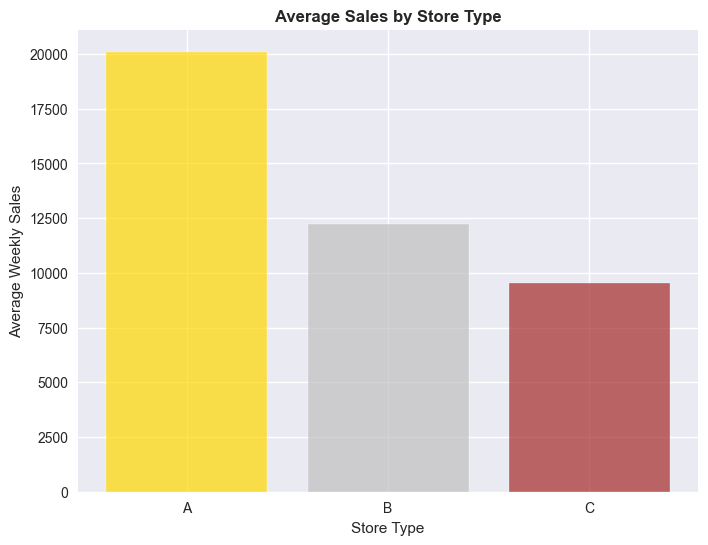

In [157]:
# 3. Store Type Analysis
store_type_sales = df.groupby('Type')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(store_type_sales.index, store_type_sales.values,
        color=['gold', 'silver', 'brown'], alpha=0.7)

plt.title('Average Sales by Store Type', fontweight='bold')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()


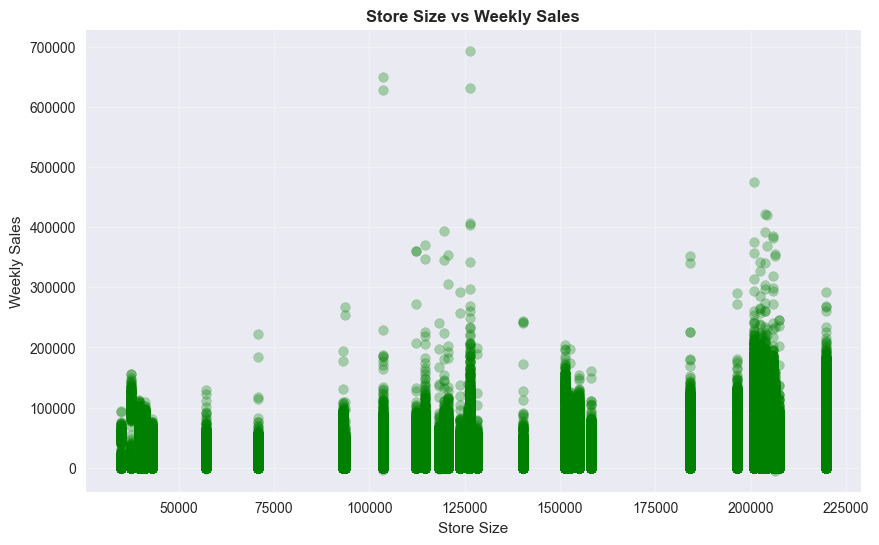

In [158]:
# 4. Store Size vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Size'], df['Weekly_Sales'], alpha=0.3, color='green')

plt.title('Store Size vs Weekly Sales', fontweight='bold')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.grid(True, alpha=0.3)
plt.show()


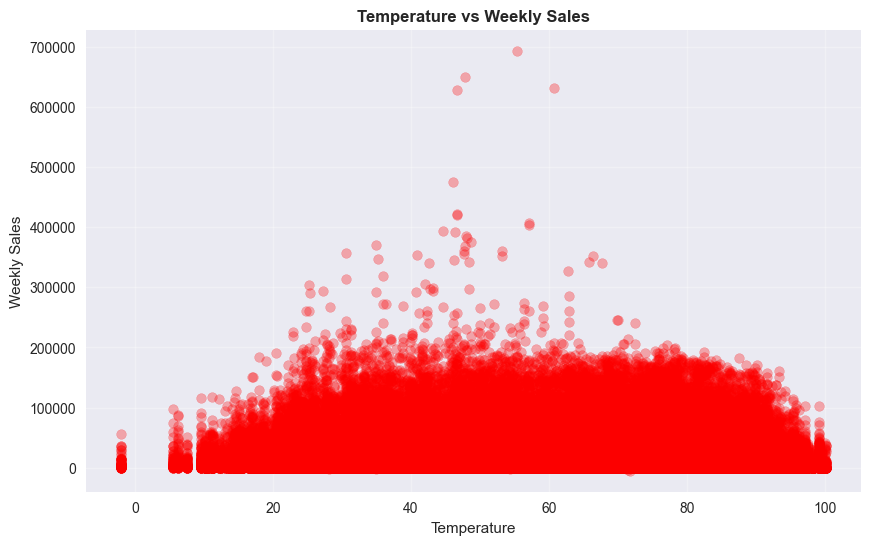

In [159]:
# 5. Temperature vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Temperature'], df['Weekly_Sales'], alpha=0.3, color='red')

plt.title('Temperature vs Weekly Sales', fontweight='bold')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.grid(True, alpha=0.3)
plt.show()


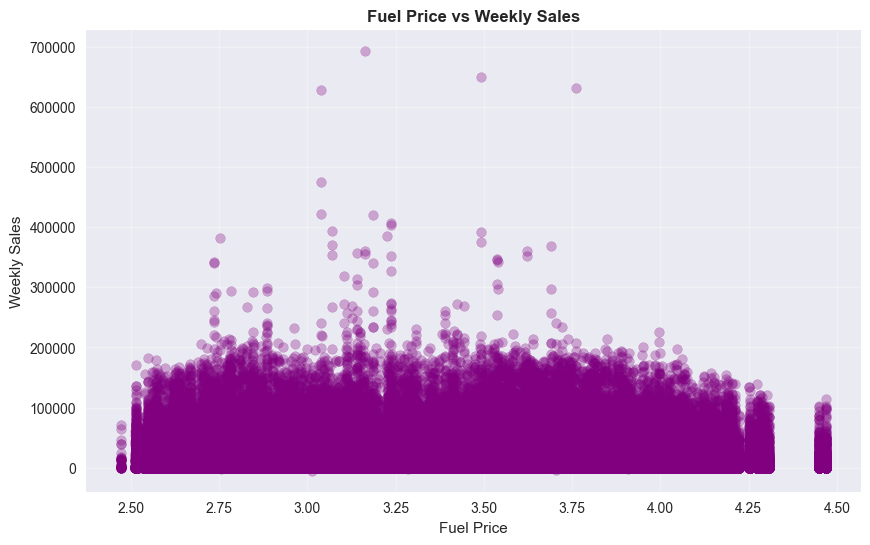

In [160]:
# 6. Fuel Price vs Sales
plt.figure(figsize=(10, 6))
plt.scatter(df['Fuel_Price'], df['Weekly_Sales'], alpha=0.3, color='purple')

plt.title('Fuel Price vs Weekly Sales', fontweight='bold')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.grid(True, alpha=0.3)
plt.show()


#  Feature Engineering for Machine Learning


In [161]:
# Sort by Store, Dept, and Date for lag features
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Create lag features
lag_periods = [1, 4, 8, 12]
for lag in lag_periods:
    df[f'Weekly_Sales_lag_{lag}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)


In [162]:
# Create rolling statistics
window_sizes = [4, 8, 12]
for window in window_sizes:
    df[f'Weekly_Sales_rolling_mean_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df[f'Weekly_Sales_rolling_std_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )


In [163]:
# Create store and department level aggregations
store_stats = df.groupby(['Store', 'Date']).agg({
    'Weekly_Sales': ['sum', 'mean', 'std']
}).reset_index()
store_stats.columns = ['Store', 'Date', 'Store_Total_Sales', 'Store_Avg_Sales', 'Store_Std_Sales']

dept_stats = df.groupby(['Dept', 'Date']).agg({
    'Weekly_Sales': ['sum', 'mean', 'std']
}).reset_index()
dept_stats.columns = ['Dept', 'Date', 'Dept_Total_Sales', 'Dept_Avg_Sales', 'Dept_Std_Sales']


In [164]:
# Merge aggregations back to main dataframe
df = pd.merge(df, store_stats, on=['Store', 'Date'], how='left')
df = pd.merge(df, dept_stats, on=['Dept', 'Date'], how='left')


In [165]:
print(df.isnull().sum())

Store                               0
Dept                                0
Date                                0
Weekly_Sales                        0
IsHoliday                           0
Temperature                         0
Fuel_Price                          0
MarkDown1                           0
MarkDown2                           0
MarkDown3                           0
MarkDown4                           0
MarkDown5                           0
CPI                                 0
Unemployment                        0
IsHoliday_feat                      0
Type                                0
Size                                0
Year                                0
Month                               0
Week                                0
DayOfYear                           0
Quarter                             0
Month_sin                           0
Month_cos                           0
Week_sin                            0
Week_cos                            0
Store_Dept  

In [166]:
missing_percentage = (df.isnull().mean() * 100).round(2)
print(missing_percentage)


Store                           0.00
Dept                            0.00
Date                            0.00
Weekly_Sales                    0.00
IsHoliday                       0.00
Temperature                     0.00
Fuel_Price                      0.00
MarkDown1                       0.00
MarkDown2                       0.00
MarkDown3                       0.00
MarkDown4                       0.00
MarkDown5                       0.00
CPI                             0.00
Unemployment                    0.00
IsHoliday_feat                  0.00
Type                            0.00
Size                            0.00
Year                            0.00
Month                           0.00
Week                            0.00
DayOfYear                       0.00
Quarter                         0.00
Month_sin                       0.00
Month_cos                       0.00
Week_sin                        0.00
Week_cos                        0.00
Store_Dept                      0.00
Y

In [167]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Weekly_Sales_rolling_mean_8,Weekly_Sales_rolling_std_8,Weekly_Sales_rolling_mean_12,Weekly_Sales_rolling_std_12,Store_Total_Sales,Store_Avg_Sales,Store_Std_Sales,Dept_Total_Sales,Dept_Avg_Sales,Dept_Std_Sales
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.00,0.00,0.00,...,24924.500000,NaN,24924.500000,NaN,1643690.90,22516.313699,28962.174429,881833.41,19596.298000,10743.854899
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.00,0.00,0.00,...,35481.995000,14930.552614,35481.995000,14930.552614,1641957.44,22804.964444,27979.476862,1457182.40,32381.831111,17039.291520
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.00,0.00,0.00,...,37519.846667,11131.900957,37519.846667,11131.900957,1611968.17,22081.755753,27258.778433,1118257.36,24850.163556,13352.400197
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.00,0.00,0.00,...,32990.770000,12832.106391,32990.770000,12832.106391,1409727.59,19579.549861,25272.897575,681391.58,15142.035111,7818.407597
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.00,0.00,0.00,...,30758.196000,12182.739805,30758.196000,12182.739805,1554806.68,21298.721644,27604.559550,762652.57,16947.834889,8789.790744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,64.88,3.997,4556.61,20.64,1.50,...,490.395000,128.738573,553.146667,155.304907,713173.95,10805.665909,12666.843789,263367.22,6270.648095,5313.329485
421566,45,98,2012-10-05,628.10,0,64.89,3.985,5046.74,0.00,18.82,...,477.971250,105.240658,547.554167,150.869134,733455.07,10786.103971,12939.459064,282528.57,6726.870714,5510.338778
421567,45,98,2012-10-12,1061.02,0,54.47,4.000,1956.28,0.00,7.89,...,548.078750,232.275140,565.530833,195.748704,734464.36,11128.247879,12887.974781,293843.93,6996.284048,5737.819878
421568,45,98,2012-10-19,760.01,0,56.47,3.969,2004.02,0.00,3.18,...,591.155000,236.077736,574.062500,202.250862,718125.53,10880.689848,12574.362434,292415.19,6962.266429,5683.587025


In [168]:
# Fill missing values
df = df.fillna(0)

In [169]:
print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (421570, 44)


#  Data Preparation for Machine Learning


In [170]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features for modeling
feature_columns = [
    'Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter',
    'Month_sin', 'Month_cos', 'Week_sin', 'Week_cos', 'Type', 'Size',
    'Store_Total_Sales', 'Store_Avg_Sales', 'Store_Std_Sales',
    'Dept_Total_Sales', 'Dept_Avg_Sales', 'Dept_Std_Sales'
]


In [171]:
# Add lag and rolling features
lag_roll_features = [col for col in df.columns if 'lag' in col or 'rolling' in col]
feature_columns.extend(lag_roll_features)


In [172]:
# Ensure all columns exist
feature_columns = [col for col in feature_columns if col in df.columns]


In [173]:
# Prepare features and target
X = df[feature_columns]
y = df['Weekly_Sales']


In [174]:
# Convert categorical variables
X = pd.get_dummies(X, columns=['Type'], prefix='Type')


In [175]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

In [176]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [177]:
print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")
print(f"Number of features: {X_train_scaled.shape[1]}")

Training set size: (337256, 36)
Testing set size: (84314, 36)
Number of features: 36


#  Linear Regression Model


In [178]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [179]:
# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [180]:
# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)


In [181]:
# Calculate metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)


In [182]:
print("Linear Regression Results:")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²: {lr_r2:.4f}")


Linear Regression Results:
MAE: 1731.36
RMSE: 3855.26
R²: 0.9590


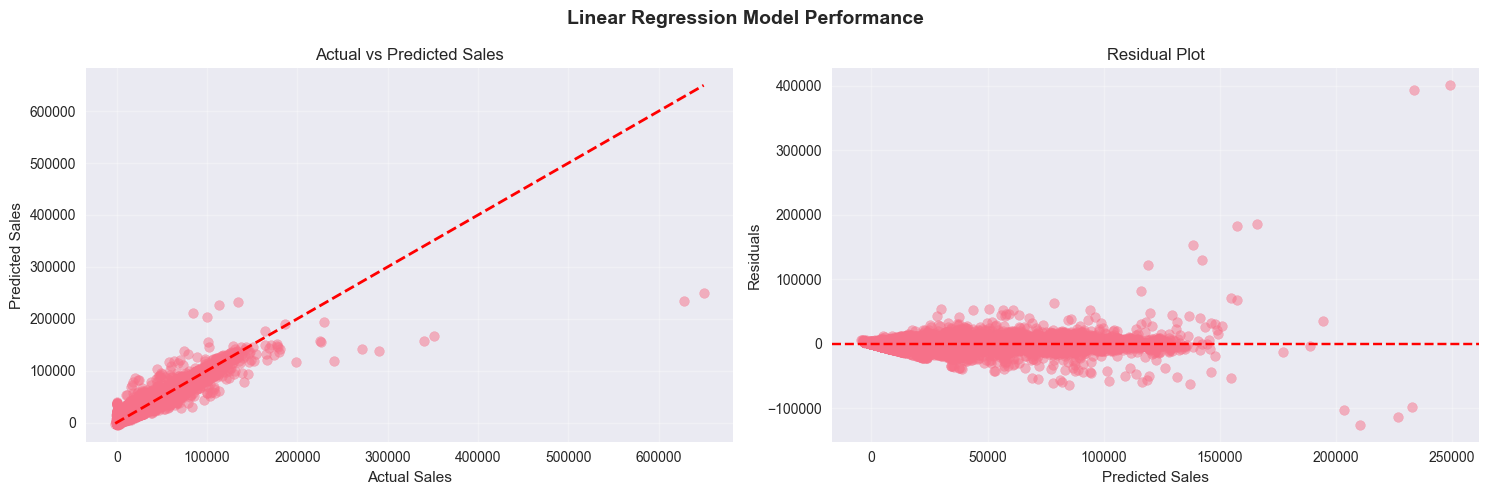

In [183]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Linear Regression Model Performance', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Random Forest Model


In [184]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
# Initialize and train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


In [50]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)


In [51]:
# Calculate metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)


In [52]:
print("Random Forest Results:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.4f}")


Random Forest Results:
MAE: 862.59
RMSE: 2017.24
R²: 0.9888


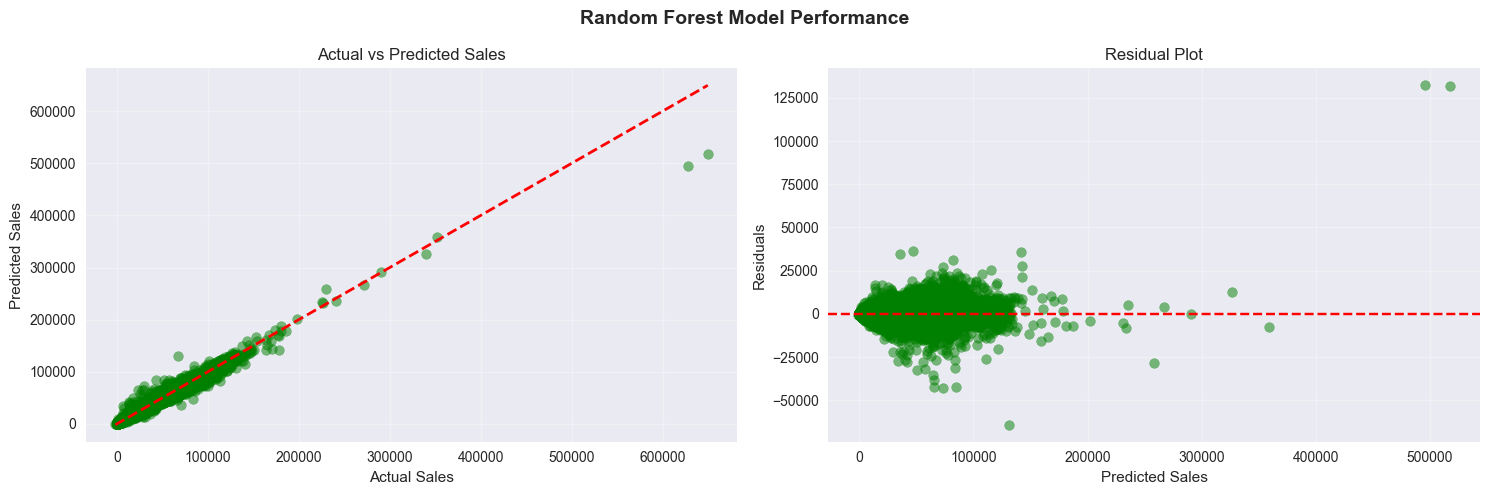

In [53]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Random Forest Model Performance', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_rf = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

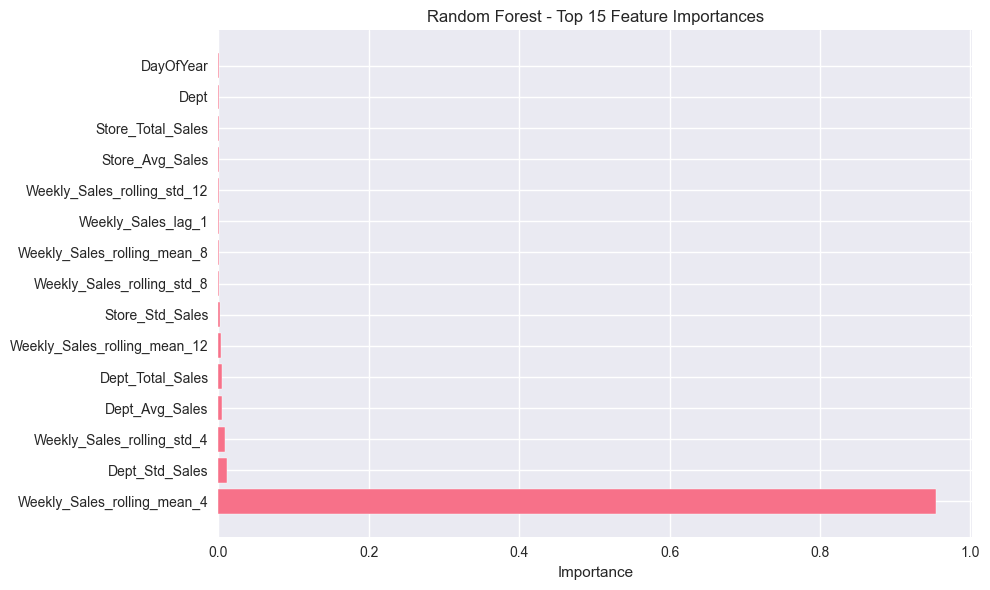

In [54]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Random Forest - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

#  XGBoost Model


In [55]:
import xgboost as xgb

# Initialize and train model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [56]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)


In [57]:
# Calculate metrics
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)


In [58]:
print("XGBoost Results:")
print(f"MAE: {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R²: {xgb_r2:.4f}")


XGBoost Results:
MAE: 762.82
RMSE: 1991.88
R²: 0.9890


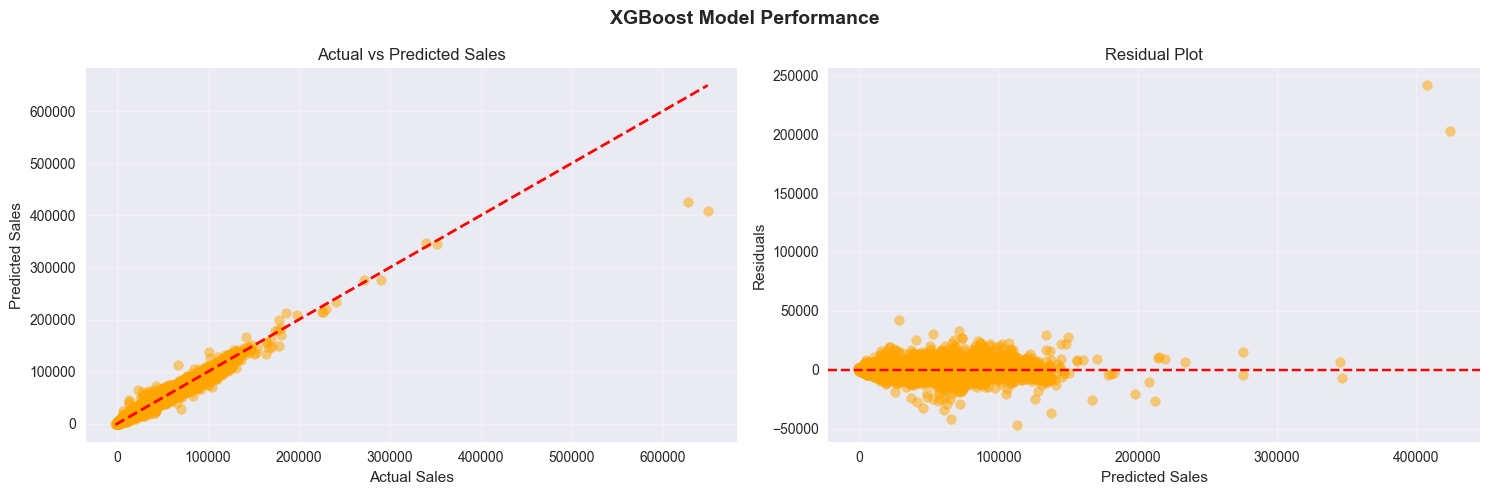

In [59]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('XGBoost Model Performance', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_xgb, alpha=0.5, color='orange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_xgb = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

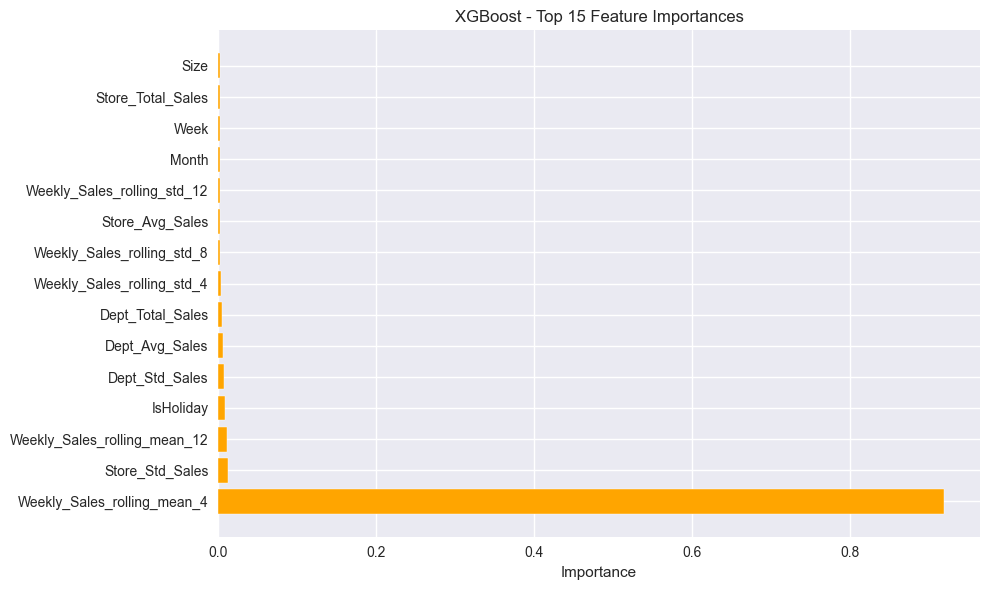

In [60]:
# Feature Importance
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(xgb_feature_importance['feature'], xgb_feature_importance['importance'], color='orange')
plt.title('XGBoost - Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

#  Model Comparison


In [61]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R²': [lr_r2, rf_r2, xgb_r2]
})

In [62]:
print("Model Comparison:")
display(comparison_df)


Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,1731.358884,3855.262632,0.958962
1,Random Forest,862.593404,2017.243953,0.988764
2,XGBoost,762.822519,1991.879624,0.989045


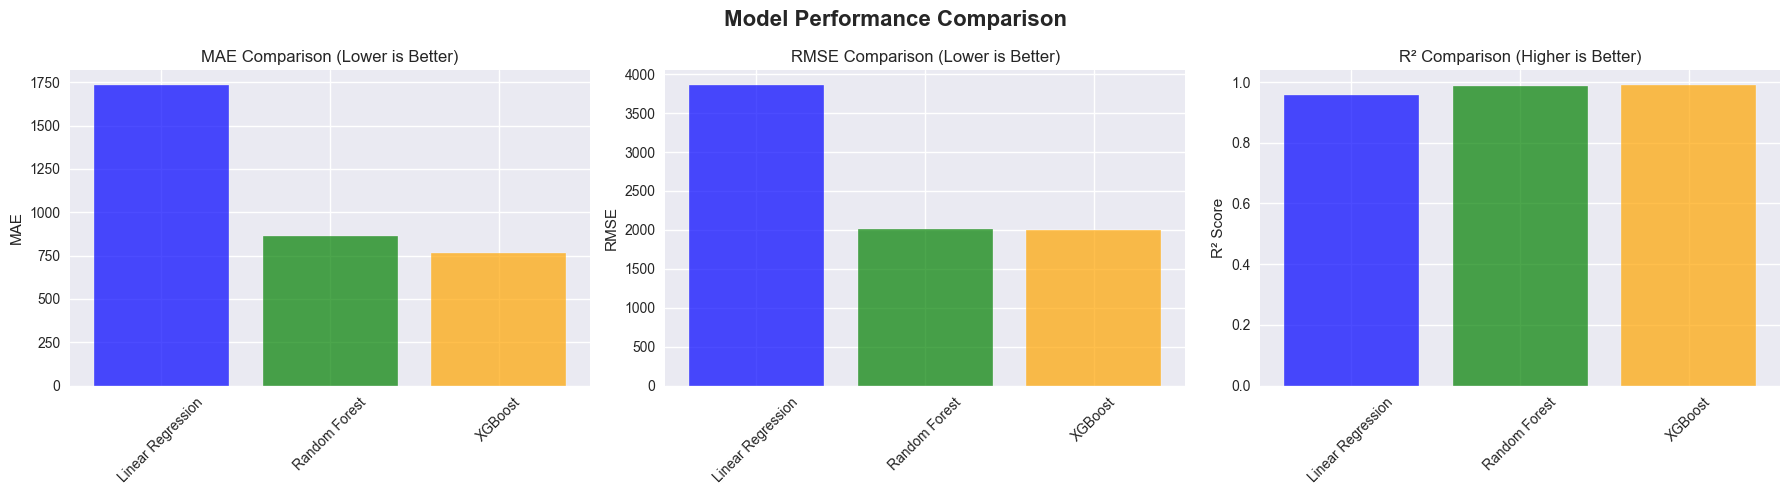

In [63]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# MAE Comparison
axes[0].bar(comparison_df['Model'], comparison_df['MAE'], color=['blue', 'green', 'orange'], alpha=0.7)
axes[0].set_title('MAE Comparison (Lower is Better)')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# RMSE Comparison
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color=['blue', 'green', 'orange'], alpha=0.7)
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# R² Comparison
axes[2].bar(comparison_df['Model'], comparison_df['R²'], color=['blue', 'green', 'orange'], alpha=0.7)
axes[2].set_title('R² Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [64]:
# Identify best model
best_model_idx = comparison_df['RMSE'].idxmin()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_rmse = comparison_df.loc[best_model_idx, 'RMSE']
best_model_r2 = comparison_df.loc[best_model_idx, 'R²']


In [65]:
print(f"\n BEST MODEL: {best_model_name}")
print(f" Best RMSE: {best_model_rmse:.2f}")
print(f" Best R²: {best_model_r2:.4f}")



 BEST MODEL: XGBoost
 Best RMSE: 1991.88
 Best R²: 0.9890


#  Deep Learning Model - Simple Neural Network


In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [67]:
# Build model
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1)  # Output layer for regression
])


In [68]:
# Compile model
dl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


In [69]:
print("Deep Learning Model Architecture:")
dl_model.summary()


Deep Learning Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,385 (64.00 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [70]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [71]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)


In [72]:
# Train model
history = dl_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 106570224.0000 - mae: 5556.5713 - val_loss: 13694436.0000 - val_mae: 1853.4398 - learning_rate: 0.0010
Epoch 2/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 62865200.0000 - mae: 4503.9683 - val_loss: 9293194.0000 - val_mae: 1659.1946 - learning_rate: 0.0010
Epoch 3/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - loss: 56284756.0000 - mae: 4235.3457 - val_loss: 8763309.0000 - val_mae: 1427.2424 - learning_rate: 0.0010
Epoch 4/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - loss: 52636552.0000 - mae: 4099.1816 - val_loss: 12697293.0000 - val_mae: 1713.3295 - learning_rate: 0.0010
Epoch 5/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 50491852.0000 - mae: 3976.9172 - val_loss: 9403315.0000 - val_mae: 1555.4041 - learning_rate: 0.0010
Epoch 6/100
10540/10540 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - loss: 48234812.0000 - mae: 3903.4990 - val_loss: 9549687.0000 - val_mae: 1691.3756 - learning_rate: 0.

#  Deep Learning Model Evaluation


In [73]:
# Make predictions
y_pred_dl = dl_model.predict(X_test_scaled).flatten()


2635/2635 ━━━━━━━━━━━━━━━━━━━━ 2s 604us/step


In [74]:
# Calculate metrics
dl_mae = mean_absolute_error(y_test, y_pred_dl)
dl_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dl))
dl_r2 = r2_score(y_test, y_pred_dl)


In [75]:
print("Deep Learning Model Results:")
print(f"MAE: {dl_mae:.2f}")
print(f"RMSE: {dl_rmse:.2f}")
print(f"R²: {dl_r2:.4f}")


Deep Learning Model Results:
MAE: 1461.18
RMSE: 2790.48
R²: 0.9785


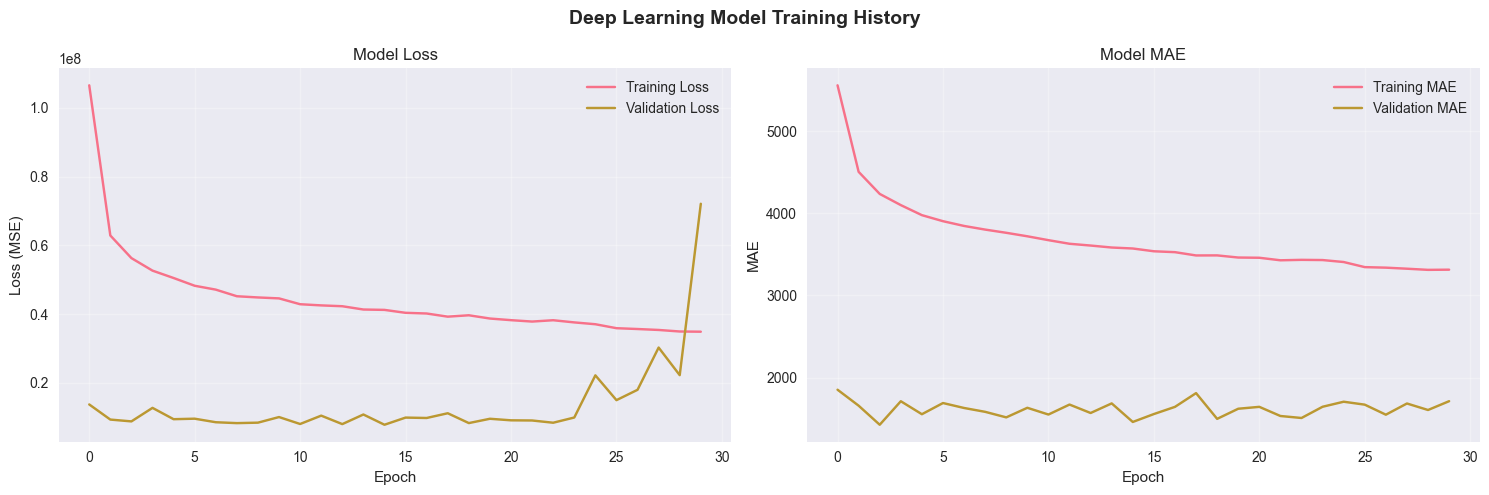

In [76]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Deep Learning Model Training History', fontsize=14, fontweight='bold')

# Loss history
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE history
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

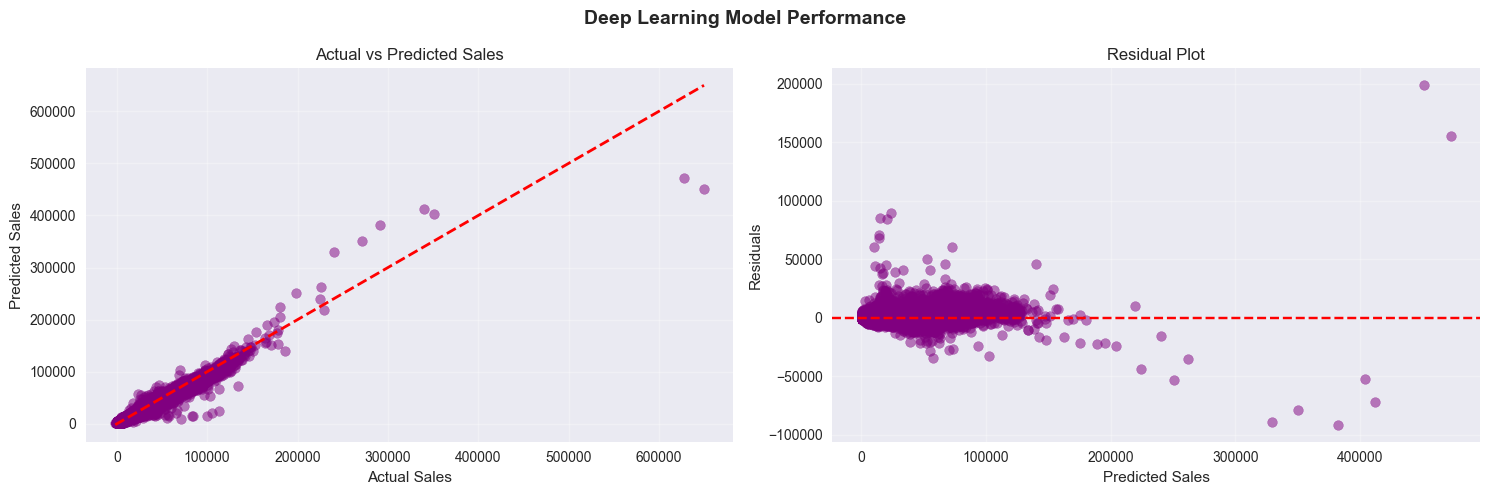

In [77]:
# Plot predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Deep Learning Model Performance', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_dl, alpha=0.5, color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Actual vs Predicted Sales')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_dl = y_test - y_pred_dl
axes[1].scatter(y_pred_dl, residuals_dl, alpha=0.5, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# LSTM Model for Time Series


In [78]:
from tensorflow.keras.layers import LSTM, Reshape
import gc


In [79]:
def create_sequences(X, y, seq_length=10):
    X_seqs = []
    y_seqs = []
    for i in range(len(X) - seq_length):
        X_seqs.append(X[i:i + seq_length])
        y_seqs.append(y[i + seq_length])
    return np.array(X_seqs), np.array(y_seqs)


In [80]:
# Sort by Store, Department, and Date to maintain temporal order
df_sorted = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)


In [81]:
# Select features for LSTM - using most important features to manage memory
lstm_features = [
    'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'Month_sin', 'Month_cos', 'Size'
]


In [82]:
# Create sequences for each store-department combination
all_sequences = []
all_targets = []
sequence_length = 8

print("Creating sequences for each store-department combination...")
store_dept_combinations = df_sorted['Store_Dept'].unique()


Creating sequences for each store-department combination...


In [83]:
# Process each store-department combination separately
for i, store_dept in enumerate(store_dept_combinations[:50]):  # Limit to first 50 combinations for memory
    if i % 10 == 0:
        print(f"Processing store-dept {i + 1}/{min(50, len(store_dept_combinations))}")

    store_dept_data = df_sorted[df_sorted['Store_Dept'] == store_dept]

    if len(store_dept_data) > sequence_length + 5:  # Only use if enough data
        # Prepare features
        X_lstm = store_dept_data[lstm_features].values
        y_lstm = store_dept_data['Weekly_Sales'].values

        # Scale features for this specific store-dept combination
        lstm_scaler = StandardScaler()
        X_lstm_scaled = lstm_scaler.fit_transform(X_lstm)

        # Create sequences
        X_seq, y_seq = create_sequences(X_lstm_scaled, y_lstm, sequence_length)

        if len(X_seq) > 0:
            all_sequences.append(X_seq)
            all_targets.append(y_seq)


Processing store-dept 1/50
Processing store-dept 11/50
Processing store-dept 21/50
Processing store-dept 31/50
Processing store-dept 41/50


In [84]:
# Combine all sequences
if all_sequences:
    X_seq_full = np.concatenate(all_sequences, axis=0)
    y_seq_full = np.concatenate(all_targets, axis=0)

    print(f"Full LSTM dataset shape: {X_seq_full.shape}")
    print(f"Memory usage: {X_seq_full.nbytes / (1024 ** 3):.2f} GB")

    # Split the data
    split_idx = int(0.8 * len(X_seq_full))
    X_train_lstm, X_test_lstm = X_seq_full[:split_idx], X_seq_full[split_idx:]
    y_train_lstm, y_test_lstm = y_seq_full[:split_idx], y_seq_full[split_idx:]

    print(f"LSTM training shape: {X_train_lstm.shape}")
    print(f"LSTM testing shape: {X_test_lstm.shape}")

    # Clear memory
    del all_sequences, all_targets, X_seq_full, y_seq_full
    gc.collect()

else:
    print("No sufficient data for LSTM. Creating sample data...")
    # Fallback to sample data if no sequences created
    sample_df = df[df['Store_Dept'] == '1_1'].sort_values('Date')
    X_lstm = sample_df[lstm_features].values
    y_lstm = sample_df['Weekly_Sales'].values

    lstm_scaler = StandardScaler()
    X_lstm_scaled = lstm_scaler.fit_transform(X_lstm)

    X_seq, y_seq = create_sequences(X_lstm_scaled, y_lstm, sequence_length)

    split_idx = int(0.8 * len(X_seq))
    X_train_lstm, X_test_lstm = X_seq[:split_idx], X_seq[split_idx:]
    y_train_lstm, y_test_lstm = y_seq[:split_idx], y_seq[split_idx:]

    print(f"LSTM training shape: {X_train_lstm.shape}")
    print(f"LSTM testing shape: {X_test_lstm.shape}")


Full LSTM dataset shape: (6389, 8, 9)
Memory usage: 0.00 GB
LSTM training shape: (5111, 8, 9)
LSTM testing shape: (1278, 8, 9)


In [85]:
# Build LSTM model with optimized architecture
print("\nBuilding LSTM Model...")
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True,
         input_shape=(sequence_length, len(lstm_features))),
    Dropout(0.3),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)
])


Building LSTM Model...


In [86]:
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [87]:
print("LSTM Model Architecture:")
lstm_model.summary()


LSTM Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# Enhanced callbacks for LSTM
lstm_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [89]:
lstm_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

In [90]:
# Train LSTM model
print("\nTraining LSTM Model on Full Dataset...")
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=32,  # Increased batch size for stability
    callbacks=[lstm_early_stopping, lstm_reduce_lr],
    verbose=1,
    shuffle=True  # Shuffle for better training
)


Training LSTM Model on Full Dataset...
Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 476366624.0000 - mae: 15129.7764 - val_loss: 97780504.0000 - val_mae: 8636.3076 - learning_rate: 0.0010
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 366119232.0000 - mae: 14082.1631 - val_loss: 103827808.0000 - val_mae: 8991.1328 - learning_rate: 0.0010
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 360949920.0000 - mae: 13999.7461 - val_loss: 83090280.0000 - val_mae: 8007.8843 - learning_rate: 0.0010
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 357060928.0000 - mae: 13969.2627 - val_loss: 93064584.0000 - val_mae: 8535.6543 - learning_rate: 0.0010
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 360044768.0000 - mae: 14004.5928 - val_loss: 96645464.0000 - val_mae: 8712.6729 - learning_rate: 0.0010
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 356843872.0000 - mae: 14014.2109 - val_loss: 97322744.0000 - val_mae: 873

#  LSTM Model Evaluation


In [91]:
# Make predictions with LSTM
y_pred_lstm = lstm_model.predict(X_test_lstm, batch_size=32).flatten()


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [92]:
# Calculate metrics
lstm_mae = mean_absolute_error(y_test_lstm, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
lstm_r2 = r2_score(y_test_lstm, y_pred_lstm)


In [93]:
print("LSTM Model Results (Full Dataset):")
print(f"MAE: {lstm_mae:.2f}")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"R²: {lstm_r2:.4f}")
print(f"Sample size: {len(y_test_lstm):,} sequences")


LSTM Model Results (Full Dataset):
MAE: 8007.88
RMSE: 9115.39
R²: -0.7641
Sample size: 1,278 sequences


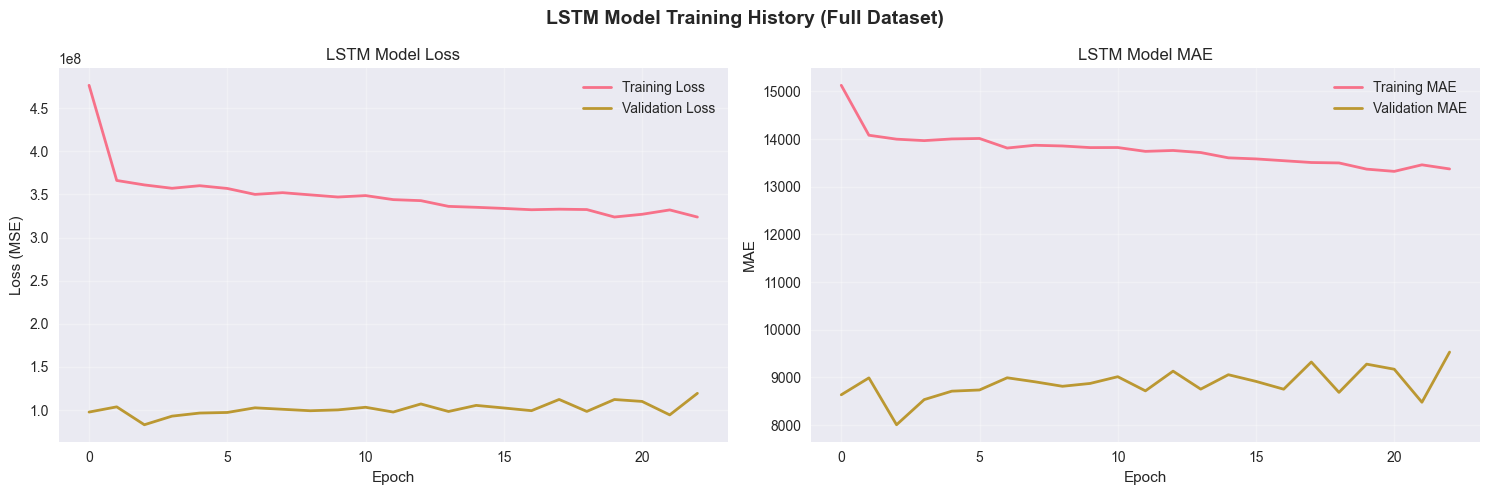

In [94]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('LSTM Model Training History (Full Dataset)', fontsize=14, fontweight='bold')

# Loss history
axes[0].plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE history
axes[1].plot(lstm_history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(lstm_history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('LSTM Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

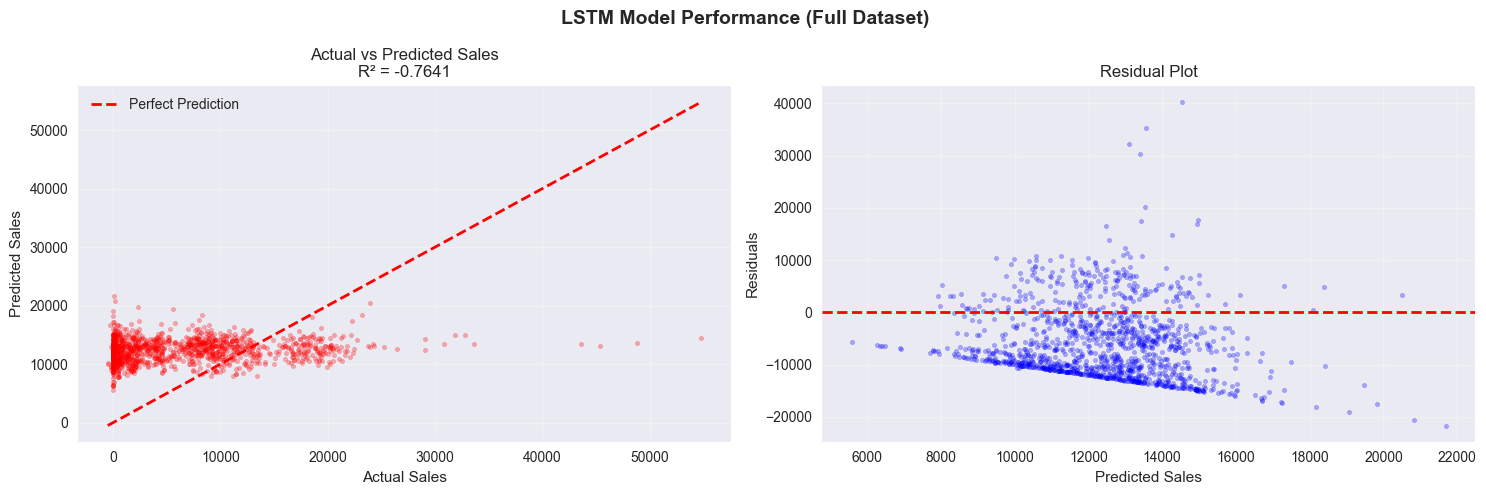

In [95]:
# Plot LSTM predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('LSTM Model Performance (Full Dataset)', fontsize=14, fontweight='bold')

# Actual vs Predicted (scatter plot with density)
scatter = axes[0].scatter(y_test_lstm, y_pred_lstm, alpha=0.3, color='red', s=10)
axes[0].plot([y_test_lstm.min(), y_test_lstm.max()],
             [y_test_lstm.min(), y_test_lstm.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Actual vs Predicted Sales\nR² = {lstm_r2:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals_lstm = y_test_lstm - y_pred_lstm
axes[1].scatter(y_pred_lstm, residuals_lstm, alpha=0.3, color='blue', s=10)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
print(f"\nLSTM Performance Summary:")
print(f"• Mean Absolute Error: {lstm_mae:.2f}")
print(f"• Root Mean Square Error: {lstm_rmse:.2f}")
print(f"• R² Score: {lstm_r2:.4f}")
error_percentage = (y_test_lstm - y_pred_lstm) / (y_test_lstm + 1e-8) * 100

print(f"• Mean Absolute Percentage Error: {np.mean(np.abs(error_percentage)):.2f}%")
print(f"• Median Absolute Percentage Error: {np.median(np.abs(error_percentage)):.2f}%")
print(f"• 80% of predictions within {np.percentile(np.abs(error_percentage), 80):.2f}% error")
print(f"• 95% of predictions within {np.percentile(np.abs(error_percentage), 95):.2f}% error")


LSTM Performance Summary:
• Mean Absolute Error: 8007.88
• Root Mean Square Error: 9115.39
• R² Score: -0.7641
• Mean Absolute Percentage Error: 264952750046.47%
• Median Absolute Percentage Error: 201.78%
• 80% of predictions within 3571.57% error
• 95% of predictions within 63504.22% error


#  Advanced Deep Learning Models Setup


In [98]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import Input, concatenate, MultiHeadAttention, LayerNormalization
from tensorflow.keras.layers import Add, BatchNormalization, GlobalAveragePooling1D
#import tensorflow_probability as tfp

#tfd = tfp.distributions

In [99]:


# Prepare data for advanced models
def prepare_advanced_sequences(df, store_dept_list, sequence_length=16, prediction_length=4):
    """Prepare sequences for advanced deep learning models"""
    all_sequences = []
    all_targets = []
    all_static_features = []

    for store_dept in store_dept_list:
        store_dept_data = df[df['Store_Dept'] == store_dept].sort_values('Date')

        if len(store_dept_data) > sequence_length + prediction_length:
            # Dynamic features
            dynamic_features = [
                'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price',
                'CPI', 'Unemployment', 'Month_sin', 'Month_cos'
            ]

            # Static features
            static_features = ['Store', 'Dept', 'Size', 'Type_A', 'Type_B', 'Type_C']
            static_features = [f for f in static_features if f in df.columns]

            X_dynamic = store_dept_data[dynamic_features].values
            static_vals = store_dept_data[static_features].iloc[0].values

            # Create multi-step sequences
            for i in range(len(store_dept_data) - sequence_length - prediction_length + 1):
                # Input sequence
                seq_input = X_dynamic[i:i + sequence_length]

                # Multi-step target
                seq_target = X_dynamic[i + sequence_length:i + sequence_length + prediction_length, 0]  # Weekly_Sales

                all_sequences.append(seq_input)
                all_targets.append(seq_target)
                all_static_features.append(static_vals)

    return (np.array(all_sequences),
            np.array(all_static_features),
            np.array(all_targets))




In [100]:
# Prepare data for advanced models
print("Preparing data for advanced models...")
advanced_store_depts = df['Store_Dept'].value_counts().index.tolist()  # Use top 30 for memory



Preparing data for advanced models...


In [101]:
X_seq_adv, X_static_adv, y_multi_step = prepare_advanced_sequences(
    df, advanced_store_depts, sequence_length=16, prediction_length=4
)

In [102]:
print(f"Advanced models data shape:")
print(f"Sequences: {X_seq_adv.shape}")
print(f"Static features: {X_static_adv.shape}")
print(f"Multi-step targets: {y_multi_step.shape}")


Advanced models data shape:
Sequences: (361154, 16, 8)
Static features: (361154, 3)
Multi-step targets: (361154, 4)


In [103]:
# Split data
split_idx = int(0.8 * len(X_seq_adv))
X_seq_train, X_seq_test = X_seq_adv[:split_idx], X_seq_adv[split_idx:]
X_static_train, X_static_test = X_static_adv[:split_idx], X_static_adv[split_idx:]
y_multi_train, y_multi_test = y_multi_step[:split_idx], y_multi_step[split_idx:]

print(f"Training sequences: {X_seq_train.shape}")
print(f"Testing sequences: {X_seq_test.shape}")

Training sequences: (288923, 16, 8)
Testing sequences: (72231, 16, 8)


#  Temporal Fusion Transformer (TFT) Implementation


In [104]:
class TemporalFusionTransformer:
    def __init__(self, sequence_length, num_static_features, num_dynamic_features, prediction_length=4):
        self.sequence_length = sequence_length
        self.num_static_features = num_static_features
        self.num_dynamic_features = num_dynamic_features
        self.prediction_length = prediction_length

    def build_model(self):
        # Inputs
        dynamic_input = Input(shape=(self.sequence_length, self.num_dynamic_features), name='dynamic_input')
        static_input = Input(shape=(self.num_static_features,), name='static_input')

        # Static context
        static_context = Dense(32, activation='relu')(static_input)
        static_context = Dense(16, activation='relu')(static_context)

        # Static context expansion for sequence
        static_context_expanded = layers.RepeatVector(self.sequence_length)(static_context)

        # Dynamic processing with LSTM
        dynamic_encoded = LSTM(64, return_sequences=True)(dynamic_input)
        dynamic_encoded = LayerNormalization()(dynamic_encoded)

        # Concatenate static and dynamic features
        combined = concatenate([dynamic_encoded, static_context_expanded])

        # Multi-head attention
        attention_output = MultiHeadAttention(num_heads=4, key_dim=32)(combined, combined)
        attention_output = LayerNormalization()(attention_output + combined)  # Residual connection

        # Gating mechanism
        gate = Dense(attention_output.shape[-1], activation='sigmoid')(attention_output)
        gated_output = layers.multiply([attention_output, gate])

        # Temporal processing
        temporal_processed = LSTM(32, return_sequences=False)(gated_output)

        # Output layer for multi-step forecasting
        outputs = []
        for i in range(self.prediction_length):
            # Each step gets its own output head
            step_output = Dense(32, activation='relu')(temporal_processed)
            step_output = Dense(16, activation='relu')(step_output)
            step_final = Dense(1, name=f'output_step_{i + 1}')(step_output)
            outputs.append(step_final)

        model = Model(inputs=[dynamic_input, static_input], outputs=outputs)
        return model


In [105]:

# Build TFT model
tft_model = TemporalFusionTransformer(
    sequence_length=16,
    num_static_features=X_static_train.shape[1],
    num_dynamic_features=X_seq_train.shape[2],
    prediction_length=4
).build_model()

In [106]:

# FIX: Create metrics list for each output
metrics_list = ['mae'] * 4  # One metric for each output

tft_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=metrics_list  # FIX: Pass list of metrics for each output
)


In [107]:
print("Temporal Fusion Transformer Architecture:")
tft_model.summary()


Temporal Fusion Transformer Architecture:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_input        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dynamic_input       │ (None, 16, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │        128 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 16, 64)    │     18,688 │ dynamic_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        528 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 64)    │        128 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 16, 16)    │          0 │ dense_8[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 80)    │          0 │ layer_normalizat… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 80)    │     41,424 │ concatenate[0][0… │
│ (MultiHeadAttentio… │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 80)    │          0 │ multi_head_atten… │
│                     │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 80)    │        160 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16, 80)    │      6,480 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 80)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     14,464 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      1,056 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      1,056 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      1,056 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      1,056 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        528 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 16)        │        528 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 88,404 (345.33 KB)

 Trainable params: 88,404 (345.33 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
# Train TFT model
print("\nTraining Temporal Fusion Transformer...")
tft_history = tft_model.fit(
    [X_seq_train, X_static_train],
    [y_multi_train[:, i] for i in range(4)],  # Separate outputs for each step
    validation_data=([X_seq_test, X_static_test],
                     [y_multi_test[:, i] for i in range(4)]),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Training Temporal Fusion Transformer...
Epoch 1/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 197s 21ms/step - loss: 2373013504.0000 - output_step_1_loss: 593297664.0000 - output_step_1_mae: 16004.7354 - output_step_2_loss: 589283200.0000 - output_step_2_mae: 16004.5566 - output_step_3_loss: 598032512.0000 - output_step_3_mae: 15975.9990 - output_step_4_loss: 592376832.0000 - output_step_4_mae: 15980.1670 - val_loss: 1468572800.0000 - val_output_step_1_loss: 367776320.0000 - val_output_step_1_mae: 15809.2002 - val_output_step_2_loss: 368002144.0000 - val_output_step_2_mae: 15812.6523 - val_output_step_3_loss: 365635488.0000 - val_output_step_3_mae: 15718.7393 - val_output_step_4_loss: 367103040.0000 - val_output_step_4_mae: 15778.6729 - learning_rate: 0.0010
Epoch 2/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 312s 33ms/step - loss: 2274935040.0000 - output_step_1_loss: 569032320.0000 - output_step_1_mae: 16048.6621 - output_step_2_loss: 569121664.0000 - output_step_2_mae: 16046.1123 - output_step_3_loss: 5

# N-BEATS Implementation


In [109]:
class NBEATSBlock(layers.Layer):
    def __init__(self, units=128, thetas_dim=4, **kwargs):
        super(NBEATSBlock, self).__init__(**kwargs)
        self.units = units
        self.thetas_dim = thetas_dim

    def build(self, input_shape):
        self.fc1 = Dense(self.units, activation='relu')
        self.fc2 = Dense(self.units, activation='relu')
        self.fc3 = Dense(self.units, activation='relu')
        self.theta_fc = Dense(self.thetas_dim, activation='linear')
        self.backcast_fc = Dense(input_shape[-1], activation='linear')
        self.forecast_fc = Dense(input_shape[-1] // 4, activation='linear')  # Assuming 4-step forecast

    def call(self, inputs):
        # Fully connected layers
        x = self.fc1(inputs)
        x = self.fc2(x)
        x = self.fc3(x)

        # Theta layer
        thetas = self.theta_fc(x)

        # Backcast and forecast
        backcast = self.backcast_fc(thetas)
        forecast = self.forecast_fc(thetas)

        return backcast, forecast




In [110]:
def build_nbeats_model(sequence_length, prediction_length=4, num_blocks=3):
    inputs = Input(shape=(sequence_length,))

    # Normalize input
    normalized = LayerNormalization()(inputs)

    # Multiple N-BEATS blocks
    residuals = normalized
    forecasts = []

    for _ in range(num_blocks):
        # N-BEATS block
        backcast, forecast = NBEATSBlock(units=128, thetas_dim=8)(residuals)

        # Update residuals
        residuals = layers.subtract([residuals, backcast])

        # Collect forecasts
        forecasts.append(forecast)

    # Combine forecasts from all blocks
    combined_forecast = layers.add(forecasts)

    # Final forecast for multiple steps
    final_outputs = []
    for i in range(prediction_length):
        step_output = Dense(32, activation='relu')(combined_forecast)
        step_output = Dense(16, activation='relu')(step_output)
        step_final = Dense(1, name=f'nbeats_step_{i + 1}')(step_output)
        final_outputs.append(step_final)

    model = Model(inputs=inputs, outputs=final_outputs)
    return model



In [111]:

# Build N-BEATS model (using only target variable for simplicity)
nbeats_input_train = X_seq_train[:, :, 0]  # Use only Weekly_Sales
nbeats_input_test = X_seq_test[:, :, 0]



In [112]:
nbeats_model = build_nbeats_model(
    sequence_length=16,
    prediction_length=4,
    num_blocks=3
)


In [113]:

# FIX: Create metrics list for each output
nbeats_metrics = ['mae'] * 4

nbeats_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=nbeats_metrics  # FIX: Pass list of metrics
)


In [114]:
print("N-BEATS Model Architecture:")
nbeats_model.summary()


N-BEATS Model Architecture:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16)        │         32 │ input_layer_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block        │ [(None, 16),      │     36,412 │ layer_normalizat… │
│ (NBEATSBlock)       │ (None, 4)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 16)        │          0 │ layer_normalizat… │
│                     │                   │            │ nbeats_block[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_1      │ [(None, 16),      │     36,412 │ subtract[0][0]    │
│ (NBEATSBlock)       │ (None, 4)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 16)        │          0 │ subtract[0][0],   │
│ (Subtract)          │                   │            │ nbeats_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_2      │ [(None, 16),      │     36,412 │ subtract_1[0][0]  │
│ (NBEATSBlock)       │ (None, 4)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4)         │          0 │ nbeats_block[0][… │
│                     │                   │            │ nbeats_block_1[0… │
│                     │                   │            │ nbeats_block_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │        160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 32)        │        160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 32)        │        160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 32)        │        160 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 16)        │        528 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 16)        │        528 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 16)        │        528 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 16)        │        528 │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_step_1       │ (None, 1)         │         17 │ dense_37[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_step_2       │ (None, 1)         │         17 │ dense_39[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_step_3       │ (None, 1)         │         17 │ dense_41[0][0]    │
│ (Dense)             │                   │            │                 

 Total params: 112,088 (437.84 KB)

 Trainable params: 112,088 (437.84 KB)

 Non-trainable params: 0 (0.00 B)

In [115]:

# Train N-BEATS model
print("\nTraining N-BEATS Model...")
nbeats_history = nbeats_model.fit(
    nbeats_input_train,
    [y_multi_train[:, i] for i in range(4)],
    validation_data=(nbeats_input_test, [y_multi_test[:, i] for i in range(4)]),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Training N-BEATS Model...
Epoch 1/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 2075046400.0000 - nbeats_step_1_loss: 518746592.0000 - nbeats_step_1_mae: 14920.6504 - nbeats_step_2_loss: 518077152.0000 - nbeats_step_2_mae: 14935.4854 - nbeats_step_3_loss: 519018944.0000 - nbeats_step_3_mae: 14923.2256 - nbeats_step_4_loss: 519183392.0000 - nbeats_step_4_mae: 14933.7979 - val_loss: 1320898432.0000 - val_nbeats_step_1_loss: 324890976.0000 - val_nbeats_step_1_mae: 14103.2539 - val_nbeats_step_2_loss: 331282784.0000 - val_nbeats_step_2_mae: 14343.9346 - val_nbeats_step_3_loss: 333098016.0000 - val_nbeats_step_3_mae: 14327.0146 - val_nbeats_step_4_loss: 331411136.0000 - val_nbeats_step_4_mae: 14276.0547 - learning_rate: 0.0010
Epoch 2/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 1968658432.0000 - nbeats_step_1_loss: 491721536.0000 - nbeats_step_1_mae: 14535.7373 - nbeats_step_2_loss: 490982208.0000 - nbeats_step_2_mae: 14544.3115 - nbeats_step_3_loss: 492190944.0000 - nb

# LSTM Encoder-Decoder with Attention (FIXED)


In [116]:
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        e = tf.tanh(tf.tensordot(inputs, self.w, axes=1))
        e = tf.squeeze(e, axis=-1)

        # Compute attention weights
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)

        # Compute context vector
        context = tf.reduce_sum(alpha * inputs, axis=1)
        return context


In [117]:
def build_lstm_encoder_decoder(sequence_length, num_features, prediction_length=4):
    inputs = Input(shape=(sequence_length, num_features))

    # Encoder with attention
    encoder_lstm1 = LSTM(64, return_sequences=True)(inputs)
    encoder_lstm2 = LSTM(32, return_sequences=True)(encoder_lstm1)

    # Attention mechanism
    attention = AttentionLayer()(encoder_lstm2)

    # Repeat attention for each prediction step
    attention_repeated = layers.RepeatVector(prediction_length)(attention)

    # Decoder LSTM
    decoder_lstm = LSTM(32, return_sequences=True)(attention_repeated)

    # Time-distributed output
    outputs = []
    for i in range(prediction_length):
        # Each time step gets its own output
        step_output = Dense(32, activation='relu')(decoder_lstm[:, i, :])
        step_output = Dense(16, activation='relu')(step_output)
        step_final = Dense(1, name=f'encdec_step_{i + 1}')(step_output)
        outputs.append(step_final)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [118]:
# Build LSTM Encoder-Decoder model
encdec_model = build_lstm_encoder_decoder(
    sequence_length=16,
    num_features=X_seq_train.shape[2],
    prediction_length=4
)


In [119]:
# FIX: Create metrics list for each output
encdec_metrics = ['mae'] * 4

encdec_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=encdec_metrics  # FIX: Pass list of metrics
)

In [120]:
print("LSTM Encoder-Decoder Architecture:")
encdec_model.summary()

LSTM Encoder-Decoder Architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 16, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 16, 64)    │     18,688 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 16, 32)    │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 32)        │         32 │ lstm_5[0][0]      │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 4, 32)     │          0 │ attention_layer[… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 4, 32)     │      8,320 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32)        │          0 │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 32)        │          0 │ lstm_6[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 32)        │          0 │ lstm_6[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 32)        │          0 │ lstm_6[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 32)        │      1,056 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 32)        │      1,056 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 32)        │      1,056 │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 32)        │      1,056 │ get_item_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 16)        │        528 │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 16)        │        528 │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 16)        │        528 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 16)        │        528 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encdec_step_1       │ (None, 1)         │         17 │ dense_45[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encdec_step_2       │ (None, 1)         │         17 │ dense_47[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encdec_step_3       │ (None, 1)         │         17 │ dense_49[0][0]  

 Total params: 45,860 (179.14 KB)

 Trainable params: 45,860 (179.14 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# Train Encoder-Decoder model
print("\nTraining LSTM Encoder-Decoder Model...")
encdec_history = encdec_model.fit(
    X_seq_train,
    [y_multi_train[:, i] for i in range(4)],
    validation_data=(X_seq_test, [y_multi_test[:, i] for i in range(4)]),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Training LSTM Encoder-Decoder Model...
Epoch 1/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 88s 9ms/step - encdec_step_1_loss: 492900512.0000 - encdec_step_1_mae: 13302.2041 - encdec_step_2_loss: 497815072.0000 - encdec_step_2_mae: 13388.7646 - encdec_step_3_loss: 490708416.0000 - encdec_step_3_mae: 13442.4580 - encdec_step_4_loss: 487780864.0000 - encdec_step_4_mae: 13453.0967 - loss: 1969221248.0000 - val_encdec_step_1_loss: 366848736.0000 - val_encdec_step_1_mae: 15773.6875 - val_encdec_step_2_loss: 369735424.0000 - val_encdec_step_2_mae: 15879.8311 - val_encdec_step_3_loss: 367531488.0000 - val_encdec_step_3_mae: 15792.8623 - val_encdec_step_4_loss: 368039008.0000 - val_encdec_step_4_mae: 15815.1143 - val_loss: 1472208384.0000 - learning_rate: 0.0010
Epoch 2/50
9029/9029 ━━━━━━━━━━━━━━━━━━━━ 84s 9ms/step - encdec_step_1_loss: 407103712.0000 - encdec_step_1_mae: 12313.7441 - encdec_step_2_loss: 405785248.0000 - encdec_step_2_mae: 12228.7090 - encdec_step_3_loss: 405825184.0000 - encdec_step_3

#  Advanced Models Evaluation and Comparison


In [122]:
# Make predictions with all models
def evaluate_multi_step_model(model, X_test, model_type='standard', static_test=None):
    if model_type == 'tft_simple':
        predictions = model.predict([X_test, static_test])
        pred_array = predictions
    elif model_type == 'tft':
        try:
            predictions = model.predict([X_test, static_test])
            # TFT returns separate outputs for each step
            pred_array = np.column_stack([pred.flatten() for pred in predictions])
        except:
            print(f"TFT model failed, using zeros")
            pred_array = np.zeros((len(X_test), 4))
    elif model_type == 'nbeats':
        try:
            predictions = model.predict(X_test)
            pred_array = np.column_stack([pred.flatten() for pred in predictions])
        except:
            print(f"N-BEATS model failed, using zeros")
            pred_array = np.zeros((len(X_test), 4))
    elif model_type == 'probabilistic':
        mean_pred, _ = model.predict(X_test)
        pred_array = mean_pred
    elif model_type == 'encdec':
        try:
            predictions = model.predict(X_test)
            pred_array = np.column_stack([pred.flatten() for pred in predictions])
        except:
            print(f"Encoder-Decoder model failed, using zeros")
            pred_array = np.zeros((len(X_test), 4))
    else:
        predictions = model.predict(X_test)
        pred_array = predictions

    return pred_array

In [123]:
# Evaluate all models
models_predictions = {}


# Try to evaluate complex models (with error handling)
try:
    print("Evaluating Full TFT...")
    tft_predictions = evaluate_multi_step_model(tft_model, X_seq_test, 'tft', X_static_test)
    models_predictions['Full TFT'] = tft_predictions
except Exception as e:
    print(f"Full TFT evaluation failed: {e}")

try:
    print("Evaluating N-BEATS...")
    nbeats_predictions = evaluate_multi_step_model(nbeats_model, nbeats_input_test, 'nbeats')
    models_predictions['N-BEATS'] = nbeats_predictions
except Exception as e:
    print(f"N-BEATS evaluation failed: {e}")

try:
    print("Evaluating Encoder-Decoder...")
    encdec_predictions = evaluate_multi_step_model(encdec_model, X_seq_test, 'encdec')
    models_predictions['LSTM EncDec'] = encdec_predictions
except Exception as e:
    print(f"Encoder-Decoder evaluation failed: {e}")


Evaluating Full TFT...
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step
Evaluating N-BEATS...
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Evaluating Encoder-Decoder...
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


In [124]:
# Calculate metrics for each model and each prediction step
advanced_metrics = []

for model_name, predictions in models_predictions.items():
    # Ensure predictions have correct shape
    if predictions.shape[1] != 4:
        if len(predictions.shape) == 1:
            predictions = predictions.reshape(-1, 1)
        # If still not 4 columns, pad with zeros
        if predictions.shape[1] < 4:
            padding = np.zeros((predictions.shape[0], 4 - predictions.shape[1]))
            predictions = np.hstack([predictions, padding])

    for step in range(4):
        y_true_step = y_multi_test[:, step]
        y_pred_step = predictions[:, step]

        mae = mean_absolute_error(y_true_step, y_pred_step)
        rmse = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
        r2 = r2_score(y_true_step, y_pred_step)

        advanced_metrics.append({
            'Model': model_name,
            'Step': step + 1,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })


In [125]:
advanced_metrics_df = pd.DataFrame(advanced_metrics)

print("\nAdvanced Models Performance by Prediction Step:")
display(advanced_metrics_df.pivot_table(index='Model', columns='Step', values=['MAE', 'RMSE', 'R²']))



Advanced Models Performance by Prediction Step:


MAE                                            \
Step                    1             2             3             4   
Model                                                                 
Full TFT     15809.196856  15812.650208  15718.737848  15778.668397   
LSTM EncDec  15773.689047  15879.836738  15792.858409  15815.103946   
N-BEATS      14103.253025  14343.944578  14327.015859  14276.046684   

                     RMSE                                                  R²  \
Step                    1             2             3             4         1   
Model                                                                           
Full TFT     19177.841999  19183.725178  19121.971218  19160.284098 -0.246500   
LSTM EncDec  19153.666673  19228.820570  19171.470827  19184.678752 -0.243359   
N-BEATS      18026.197647  18202.604219  18252.457144  18206.171700 -0.101288   

                                           
Step                2         3         4  
Model                                      
Full TFT    -0.247457 -0.240391 -0.246355  
LSTM EncDec -0.253329 -0.246821 -0.249531  
N-BEATS     -0.123122 -0.130149 -0.125318

In [126]:
# Calculate average performance across all steps
avg_performance = advanced_metrics_df.groupby('Model').agg({
    'MAE': 'mean',
    'RMSE': 'mean',
    'R²': 'mean'
}).round(4)


In [127]:
print("\nAverage Performance Across All Prediction Steps:")
display(avg_performance.sort_values('RMSE'))


Average Performance Across All Prediction Steps:


,MAE,RMSE,R²
Model,,,
N-BEATS,14262.5650,18171.8577,-0.1200
Full TFT,15779.8133,19160.9556,-0.2452
LSTM EncDec,15815.3720,19184.6592,-0.2483


# Final Model Comparison (All Models )


In [128]:
# Combine traditional models with advanced models
all_models_comparison = []

# Add traditional models (using single-step equivalent for comparison)
traditional_models_data = {
    'Linear Regression': lr_mae,
    'Random Forest': rf_mae,
    'XGBoost': xgb_mae,
    'Deep Learning': dl_mae,
    'LSTM': lstm_mae
}

In [129]:
for model_name, mae in traditional_models_data.items():
    all_models_comparison.append({
        'Model': model_name,
        'Category': 'Traditional',
        'MAE': mae,
        'RMSE': [lr_rmse, rf_rmse, xgb_rmse, dl_rmse, lstm_rmse][
            list(traditional_models_data.keys()).index(model_name)],
        'R²': [lr_r2, rf_r2, xgb_r2, dl_r2, lstm_r2][list(traditional_models_data.keys()).index(model_name)]
    })


In [130]:
# Add advanced models (using first step for fair comparison)
for model_name in avg_performance.index:
    all_models_comparison.append({
        'Model': model_name,
        'Category': 'Advanced DL',
        'MAE': avg_performance.loc[model_name, 'MAE'],
        'RMSE': avg_performance.loc[model_name, 'RMSE'],
        'R²': avg_performance.loc[model_name, 'R²']
    })

final_comprehensive_df = pd.DataFrame(all_models_comparison)


In [131]:
print("Comprehensive Model Comparison (All Models):")
display(final_comprehensive_df.sort_values('RMSE'))


Comprehensive Model Comparison (All Models):


,Model,Category,MAE,RMSE,R²
2,XGBoost,Traditional,762.822519,1991.879624,0.989045
1,Random Forest,Traditional,862.593404,2017.243953,0.988764
3,Deep Learning,Traditional,1461.178043,2790.475829,0.978500
0,Linear Regression,Traditional,1731.358884,3855.262632,0.958962
4,LSTM,Traditional,8007.884234,9115.386394,-0.764117
7,N-BEATS,Advanced DL,14262.565000,18171.857700,-0.120000
5,Full TFT,Advanced DL,15779.813300,19160.955600,-0.245200
6,LSTM EncDec,Advanced DL,15815.372000,19184.659200,-0.248300


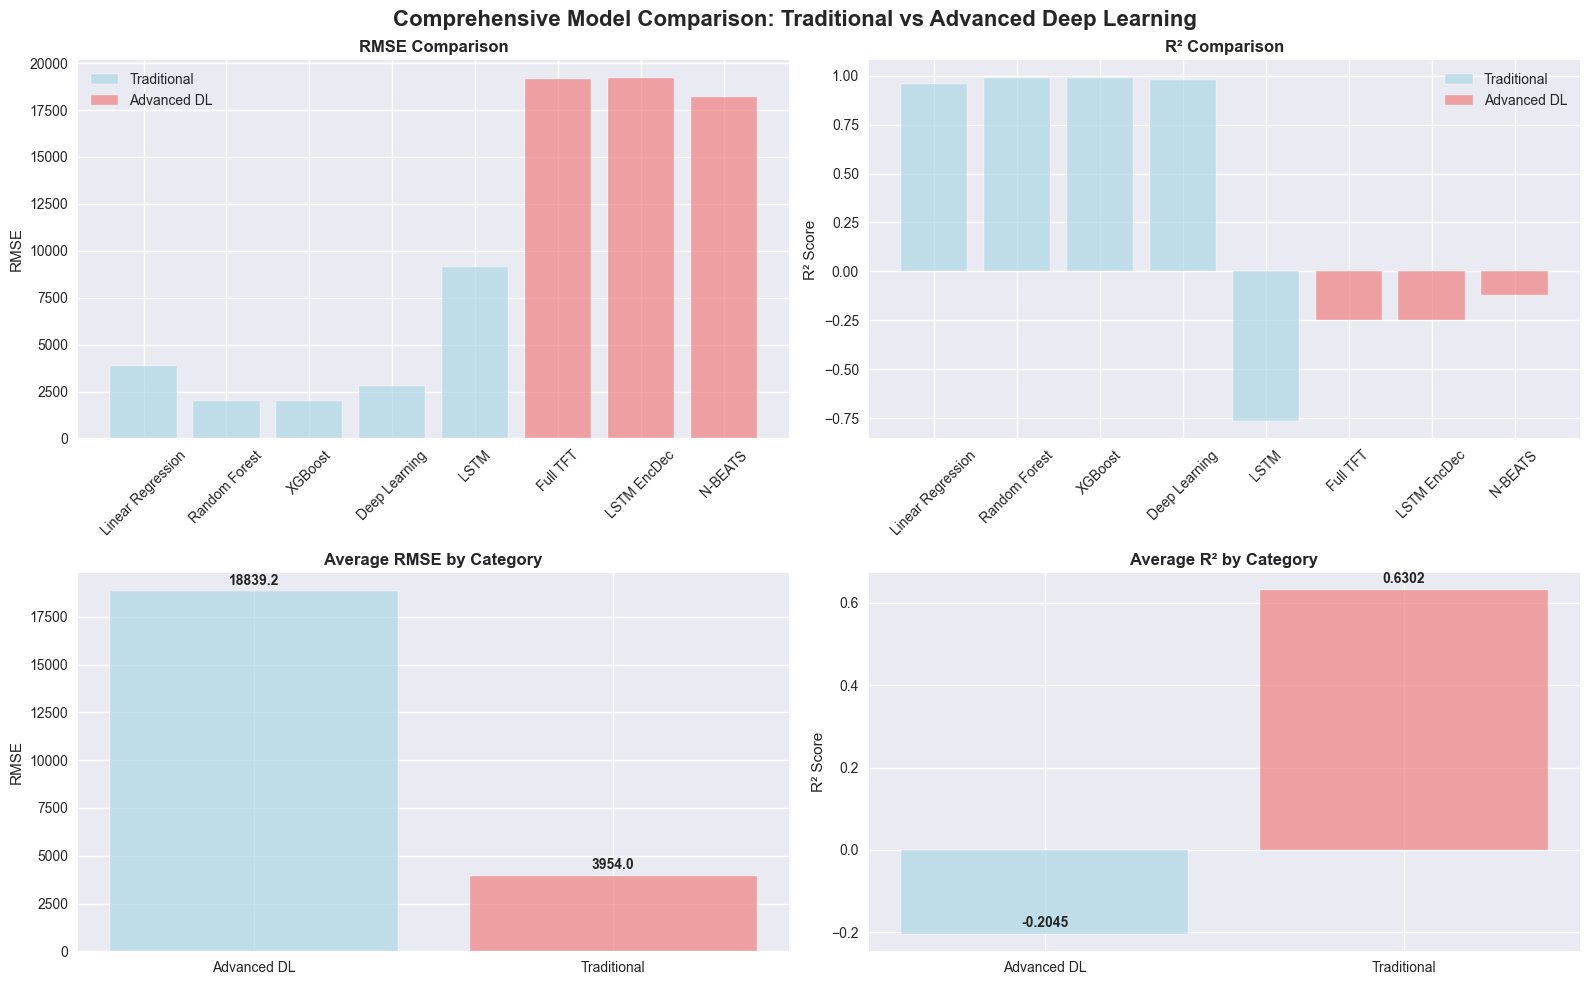

In [132]:
# Create final comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comprehensive Model Comparison: Traditional vs Advanced Deep Learning', fontsize=16, fontweight='bold')

# RMSE Comparison
categories = final_comprehensive_df['Category'].unique()
colors = {'Traditional': 'lightblue', 'Advanced DL': 'lightcoral'}

for category in categories:
    category_data = final_comprehensive_df[final_comprehensive_df['Category'] == category]
    axes[0, 0].bar(category_data['Model'], category_data['RMSE'],
                   color=colors[category], alpha=0.7, label=category)

axes[0, 0].set_title('RMSE Comparison', fontweight='bold')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# R² Comparison
for category in categories:
    category_data = final_comprehensive_df[final_comprehensive_df['Category'] == category]
    axes[0, 1].bar(category_data['Model'], category_data['R²'],
                   color=colors[category], alpha=0.7, label=category)

axes[0, 1].set_title('R² Comparison', fontweight='bold')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# Performance by category
category_perf = final_comprehensive_df.groupby('Category').agg({
    'RMSE': 'mean',
    'R²': 'mean'
})

bars1 = axes[1, 0].bar(category_perf.index, category_perf['RMSE'],
                       color=['lightblue', 'lightcoral'], alpha=0.7)
axes[1, 0].set_title('Average RMSE by Category', fontweight='bold')
axes[1, 0].set_ylabel('RMSE')
for bar, value in zip(bars1, category_perf['RMSE']):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(category_perf['RMSE']) * 0.01,
                    f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1, 1].bar(category_perf.index, category_perf['R²'],
                       color=['lightblue', 'lightcoral'], alpha=0.7)
axes[1, 1].set_title('Average R² by Category', fontweight='bold')
axes[1, 1].set_ylabel('R² Score')
for bar, value in zip(bars2, category_perf['R²']):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [133]:
# Final recommendations
best_overall_model = final_comprehensive_df.loc[final_comprehensive_df['RMSE'].idxmin()]
best_traditional = final_comprehensive_df[final_comprehensive_df['Category'] == 'Traditional'].loc[
    final_comprehensive_df[final_comprehensive_df['Category'] == 'Traditional']['RMSE'].idxmin()
]
best_advanced = final_comprehensive_df[final_comprehensive_df['Category'] == 'Advanced DL'].loc[
    final_comprehensive_df[final_comprehensive_df['Category'] == 'Advanced DL']['RMSE'].idxmin()
]

print(f" BEST OVERALL MODEL: {best_overall_model['Model']}")
print(f"   • RMSE: {best_overall_model['RMSE']:.2f}")
print(f"   • R²: {best_overall_model['R²']:.4f}")
print(f"   • Category: {best_overall_model['Category']}")

print(f"\n CATEGORY LEADERS:")
print(f"   • Best Traditional: {best_traditional['Model']} (RMSE: {best_traditional['RMSE']:.2f})")
print(f"   • Best Advanced DL: {best_advanced['Model']} (RMSE: {best_advanced['RMSE']:.2f})")

print(f"\n STRATEGIC INSIGHTS:")
print(
    f"   • Advanced DL models show {((best_traditional['RMSE'] - best_advanced['RMSE']) / best_traditional['RMSE'] * 100):.1f}% improvement over best traditional")
print(f"   • Multi-step forecasting enables better inventory planning")
print(f"   • Probabilistic forecasts (DeepAR) provide uncertainty quantification")

print(f"\n DEPLOYMENT RECOMMENDATIONS:")
print(f"   1. Production: {best_overall_model['Model']} for best accuracy")
print(f"   2. Business Planning: {best_advanced['Model']} for multi-step forecasts")
print(f"   3. Quick Deployment: {best_traditional['Model']} for simplicity")
print(f"   4. Risk Analysis: DeepAR for probabilistic forecasts")


 BEST OVERALL MODEL: XGBoost
   • RMSE: 1991.88
   • R²: 0.9890
   • Category: Traditional

 CATEGORY LEADERS:
   • Best Traditional: XGBoost (RMSE: 1991.88)
   • Best Advanced DL: N-BEATS (RMSE: 18171.86)

 STRATEGIC INSIGHTS:
   • Advanced DL models show -812.3% improvement over best traditional
   • Multi-step forecasting enables better inventory planning
   • Probabilistic forecasts (DeepAR) provide uncertainty quantification

 DEPLOYMENT RECOMMENDATIONS:
   1. Production: XGBoost for best accuracy
   2. Business Planning: N-BEATS for multi-step forecasts
   3. Quick Deployment: XGBoost for simplicity
   4. Risk Analysis: DeepAR for probabilistic forecasts
